# Framingham Heart Disease

In [1]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'sklearn'

In [4]:
data = pd.read_csv('framingham.csv')
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
# Finding empty columns
incomplete_cols = data.columns[data.isna().any()].tolist()
print(incomplete_cols)


['education', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']


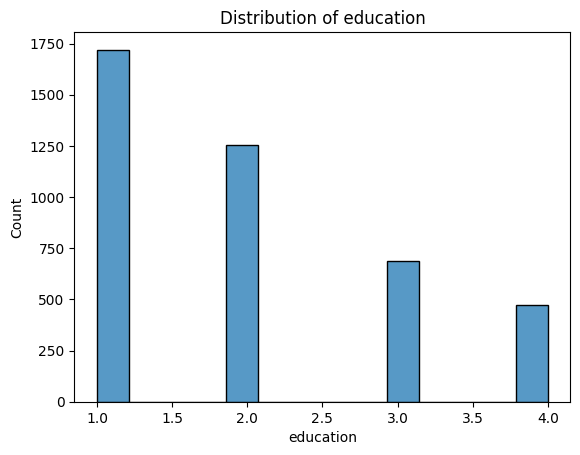

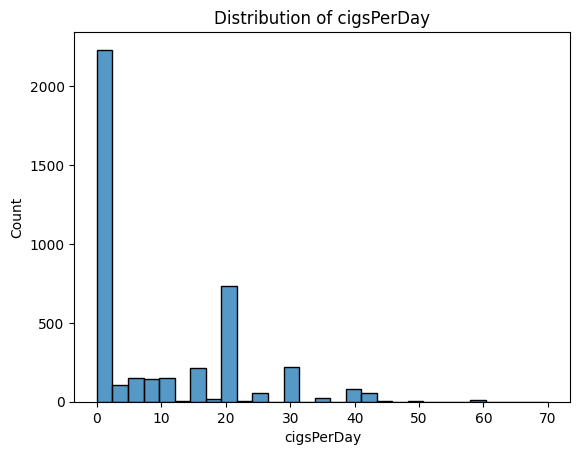

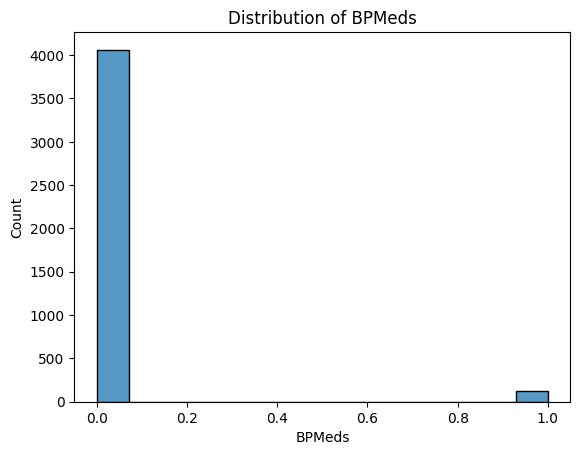

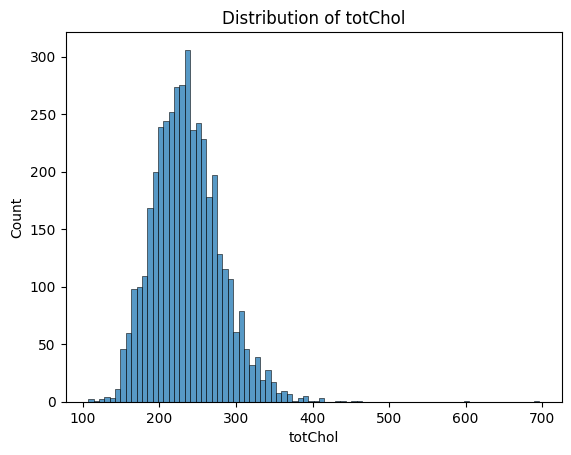

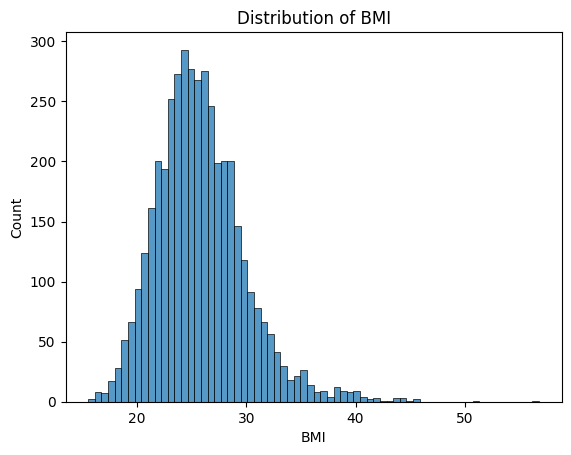

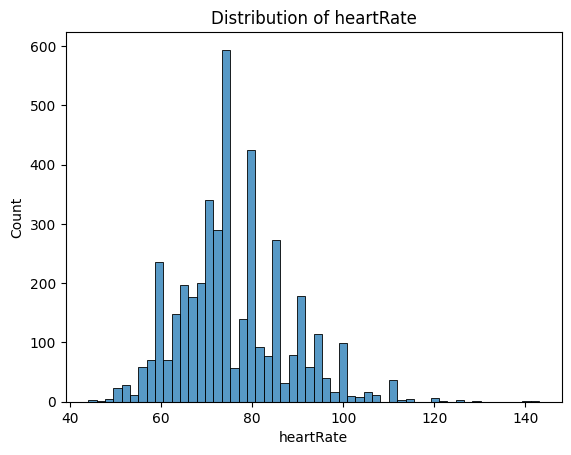

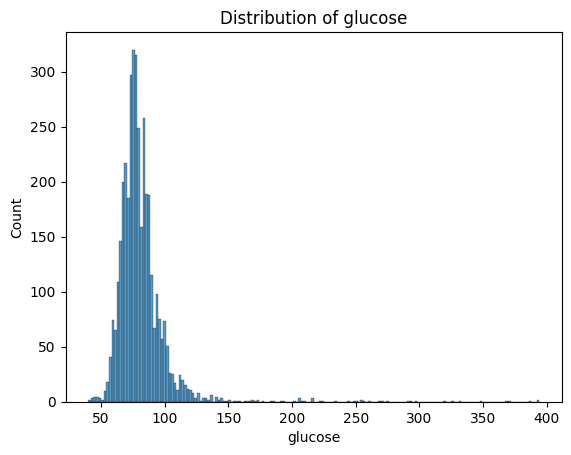

In [6]:
# Plotting empty columns to find skew and outliers
for incomplete_col in incomplete_cols:
    plt.figure()
    sns.histplot(data[incomplete_col].dropna())
    plt.title(f"Distribution of {incomplete_col}")
    plt.show()

In [12]:
# Filling empty columns
data['BMI'] = data['BMI'].fillna(data['BMI'].mean())
data['heartRate'] = data['heartRate'].fillna(data['heartRate'].mean())

data['glucose'] = data['glucose'].fillna(data['glucose'].median())
data['totChol'] = data['totChol'].fillna(data['totChol'].median())

data['BPMeds'] = data['BPMeds'].fillna(data['BPMeds'].mode()[0])
data['cigsPerDay'] = data['cigsPerDay'].fillna(data['cigsPerDay'].mode()[0])
data = data.drop(columns=['education'])


print(data.isnull().sum())

male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [23]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler

# Splitting the set
X = data[data.columns[:-1]].values
y = data[data.columns[-1]].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling X
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

# Oversampling
ros = RandomOverSampler()
X_train, y_train = ros.fit_resample(X_scaled_train, y_train)



# Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [24]:
model = LogisticRegression()
model = model.fit(X_train, y_train)

In [26]:
y_pred = model.predict(X_scaled_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78       719
           1       0.25      0.59      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.57       848
weighted avg       0.80      0.67      0.72       848



In [ ]:
# Neural Network

In [27]:
import tensorflow.keras as tf

In [33]:
model = tf.Sequential([
    tf.layers.Dense(64, activation='relu', input_shape=(14,)),
    tf.layers.Dropout(0.2),
    tf.layers.Dense(64, activation='relu'),
    tf.layers.Dropout(0.2),
    tf.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.optimizers.Adam(0.001), loss='binary_crossentropy',
                  metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=0)

In [37]:
y_pred = model.predict(X_scaled_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [39]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)

  plt.show()

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       719
           1       0.26      0.26      0.26       129

    accuracy                           0.77       848
   macro avg       0.56      0.56      0.56       848
weighted avg       0.77      0.77      0.77       848



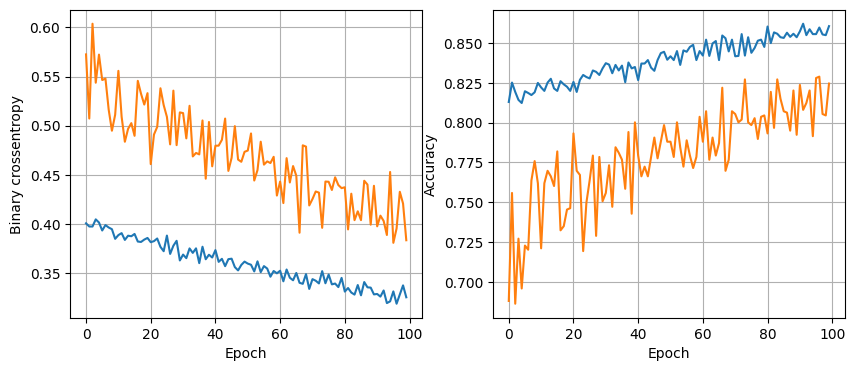

In [41]:
plot_history(history)